## **Libraray and Data Load**

In [1]:
# Operating System
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Handling
import pandas as pd
import numpy as np

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Train-Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# Explainability
import shap

# Dataset Loading (Kaggle)
import kagglehub

C:\Users\RABI SAH\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Load dataset
csv_file = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_file)

# Display first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## **Exploratory Data Analysis**

In [3]:
print("=" * 50)
print("📊 Statistical Summary")
print("=" * 50)

print(df.describe())

📊 Statistical Summary
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00 

In [4]:
print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory        : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates    : {df.duplicated().sum():,}")

class_counts = df["Class"].value_counts()
fraud_pct    = class_counts[1] / len(df) * 100

print(f"\n── Class Distribution ──────────────────")
print(f"  Legitimate : {class_counts[0]:,}  ({100-fraud_pct:.3f}%)")
print(f"  Fraud      : {class_counts[1]:,}    ({fraud_pct:.3f}%)")
print(f"  Ratio      : 1 fraud per {class_counts[0]//class_counts[1]:,} legit txns")

print(f"\n── Amount Stats by Class ───────────────")
print(df.groupby("Class")["Amount"].agg(["mean","median","max"]).rename(index={0:"Legit",1:"Fraud"}))

Shape         : 284,807 rows × 31 columns
Memory        : 70.6 MB
Missing values: 0
Duplicates    : 1,081

── Class Distribution ──────────────────
  Legitimate : 284,315  (99.827%)
  Fraud      : 492    (0.173%)
  Ratio      : 1 fraud per 577 legit txns

── Amount Stats by Class ───────────────
             mean  median       max
Class                              
Legit   88.291022   22.00  25691.16
Fraud  122.211321    9.25   2125.87


In [5]:
df = df.drop_duplicates()
print(f"After removeing duplipation         : {df.duplicated().sum():,}")
print(f"Shape after removeing duplipation   : {df.shape[0]:,} rows × {df.shape[1]} columns")

After removeing duplipation         : 0
Shape after removeing duplipation   : 283,726 rows × 31 columns


## **EDA (class distribution, Amount/Time distributions, correlation heatmap)**

In [6]:
df["Hour"] = (df["Time"] / 3600).astype(int)
df["Time_Period"] = pd.cut(
    df["Hour"],
    bins=[-1, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"]
)

In [7]:
df["Amount_Category"] = pd.cut(
    df["Amount"],
    bins=[-1, 50, 200, 1000, 5000, float("inf")],
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large",
        "Extreme"
    ]
)

In [8]:
# Convert class labels
df["Transaction_Type"] = df["Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

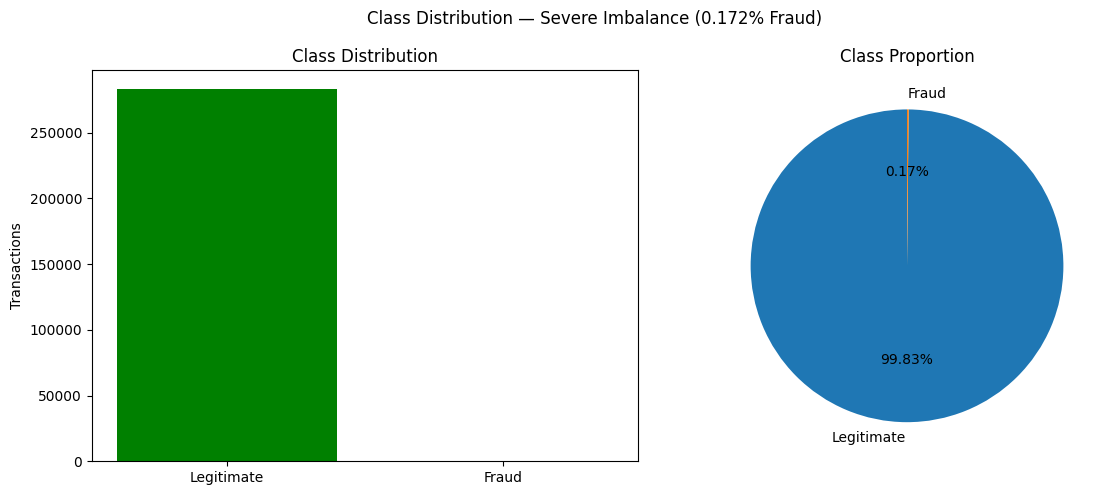

In [9]:
counts = df["Class"].value_counts()

plt.figure(figsize=(12, 5))
plt.suptitle("Class Distribution — Severe Imbalance (0.172% Fraud)")

# Bar Chart
plt.subplot(1, 2, 1)
plt.bar(["Legitimate", "Fraud"], counts, color=["green", "red"])
plt.title("Class Distribution")
plt.ylabel("Transactions")

# Pie Chart
plt.subplot(1, 2, 2)
plt.pie(
    counts,
    labels=["Legitimate", "Fraud"],
    autopct="%1.2f%%",
    startangle=90
)
plt.title("Class Proportion")

plt.tight_layout()
plt.savefig("../visuals/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

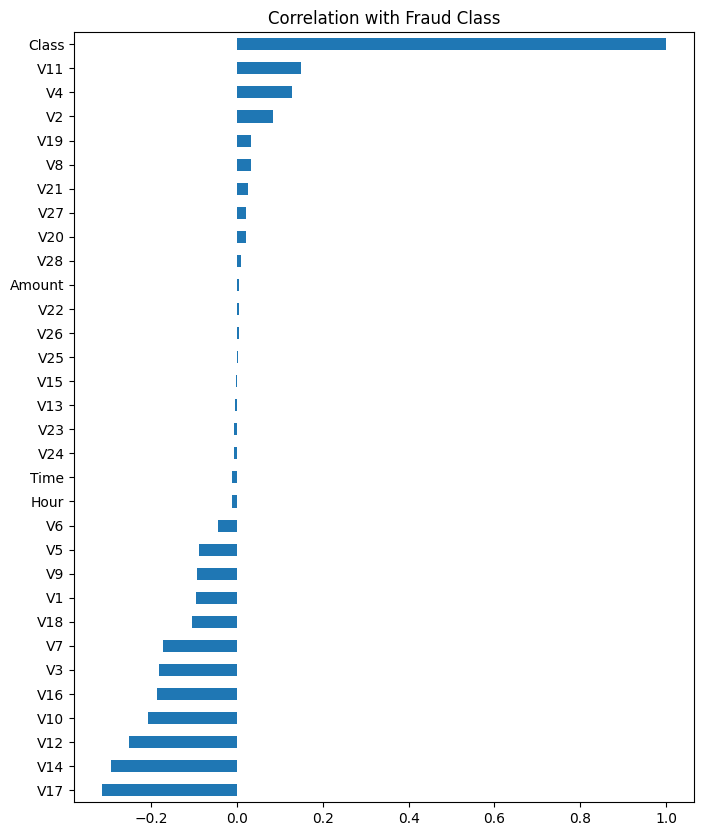

In [10]:
corr = df.corr(numeric_only=True)["Class"].sort_values()

plt.figure(figsize=(8,10))

corr.plot(kind="barh")

plt.title("Correlation with Fraud Class")
plt.savefig("../visuals/feature_correlation_fraud_class.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

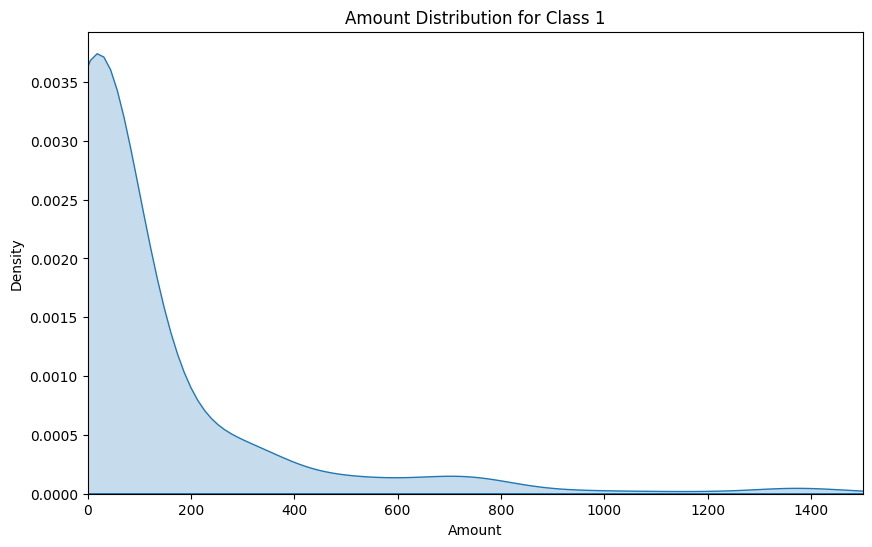

In [11]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df[df["Class"] == 1],
    x="Amount",
    fill=True
)

plt.xlim(0, 1500)
plt.title("Amount Distribution for Class 1")
plt.savefig("../visuals/kde ammount distribution for fraud.png", dpi=300, bbox_inches="tight")
plt.show()

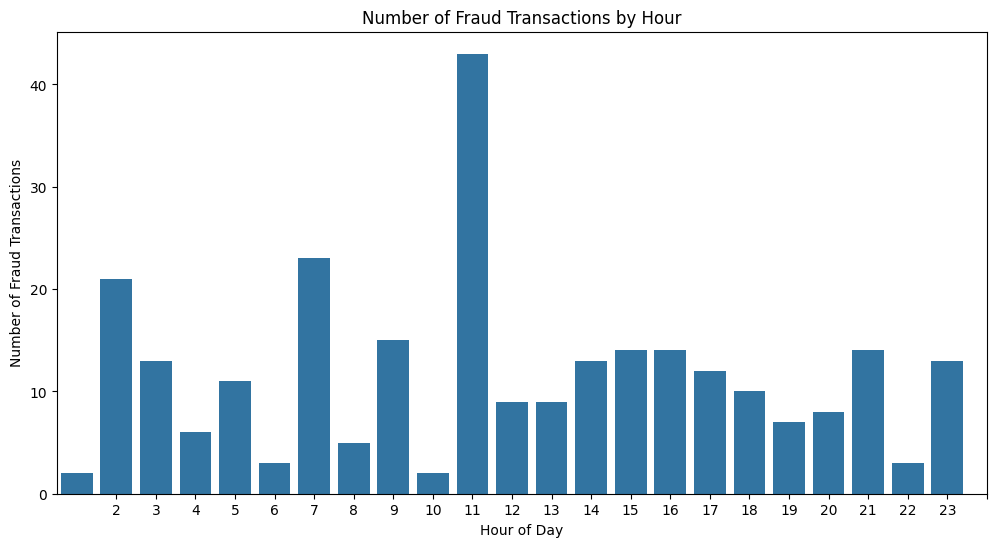

In [12]:
# Keep only fraud transactions
fraud = df[df["Class"] == 1]

# Count fraud transactions per hour
fraud_hour = fraud.groupby("Hour").size()

# Keep hour 1-23 only
fraud_hour = fraud_hour.loc[1:23]

plt.figure(figsize=(12,6))

sns.barplot(
    x=fraud_hour.index,
    y=fraud_hour.values
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraud Transactions")
plt.title("Number of Fraud Transactions by Hour")

plt.xticks(range(1, 24))

# Save figure
plt.savefig(
    "../visuals/fraud_transactions_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

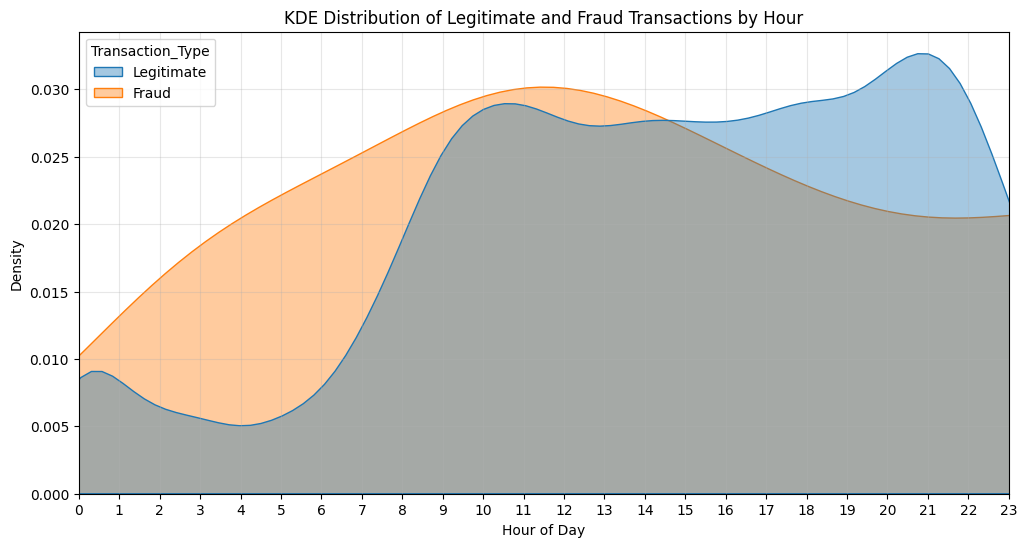

In [13]:
df["Hour"] = (df["Time"] / 3600).astype(int)

df["Transaction_Type"] = df["Class"].map({
    0: "Legitimate",
    1: "Fraud"
})

plt.figure(figsize=(12,6))

sns.kdeplot(
    data=df,
    x="Hour",
    hue="Transaction_Type",
    fill=True,
    common_norm=False,
    bw_adjust=0.8,
    alpha=0.4
)

plt.xticks(range(0,24))
plt.xlim(0,23)

plt.xlabel("Hour of Day")
plt.ylabel("Density")
plt.title("KDE Distribution of Legitimate and Fraud Transactions by Hour")

plt.grid(alpha=0.3)
plt.savefig("../visuals/kde distribution by hour.png", dpi=300, bbox_inches="tight")
plt.show()

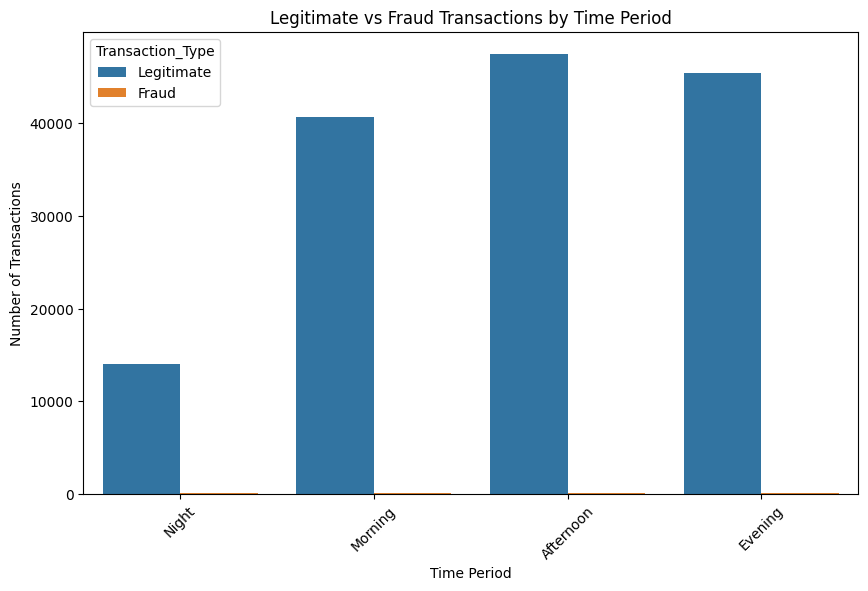

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Time_Period",
    hue="Transaction_Type"
)

plt.xlabel("Time Period")
plt.ylabel("Number of Transactions")
plt.title("Legitimate vs Fraud Transactions by Time Period")

plt.xticks(rotation=45)
plt.savefig("../visuals/Legit vs Fraud by time category.png", dpi=300, bbox_inches="tight")
plt.show()

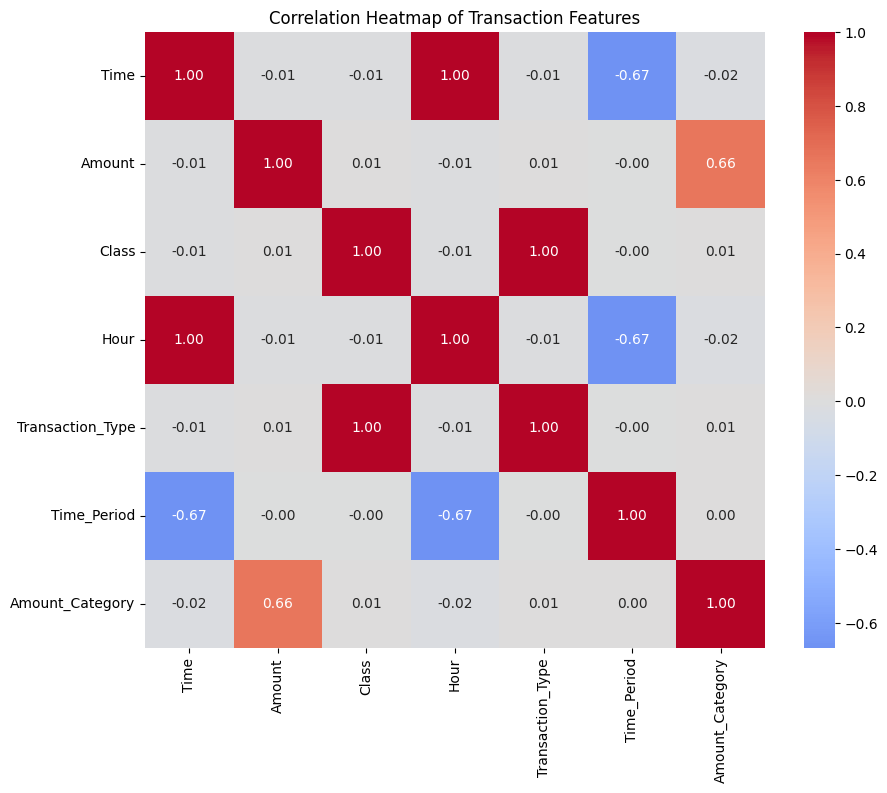

In [15]:
# Select required columns
corr_df = df[
    [
        "Time",
        "Amount",
        "Class",
        "Hour",
        "Transaction_Type",
        "Time_Period",
        "Amount_Category"
    ]
].copy()

# Convert categorical columns to numeric
corr_df["Transaction_Type"] = corr_df["Transaction_Type"].map({
    "Legitimate": 0,
    "Fraud": 1
})

corr_df["Time_Period"] = corr_df["Time_Period"].astype("category").cat.codes

corr_df["Amount_Category"] = corr_df["Amount_Category"].astype("category").cat.codes


# Correlation matrix
corr = corr_df.corr()

# Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Transaction Features")
plt.savefig(
    "../visuals/transaction_feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Train baseline models**

In [16]:
X = df.iloc[:, 0:30]
y = df.iloc[:, 30]

In [17]:
print(y.name)

Class


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#### Logistic Regression Pipeline

In [19]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0


##### Random Forest Pipeline

In [20]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


##### XGBoost Pipeline

In [21]:
xgb_pipeline = Pipeline([
    ("model", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_pipeline

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None


In [22]:
models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

In [23]:
for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(
        X_train,
        y_train
    )
    
    print(f"{name} trained successfully\n")

Training Logistic Regression...
Logistic Regression trained successfully

Training Random Forest...
Random Forest trained successfully

Training XGBoost...
XGBoost trained successfully



In [24]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    print("="*50)
    print(name)
    print("="*50)

    print(classification_report(y_test, y_pred))



Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.89      0.56      0.68        90

    accuracy                           1.00     56746
   macro avg       0.95      0.78      0.84     56746
weighted avg       1.00      1.00      1.00     56746

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.97      0.73      0.84        90

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.94      0.69      0.79        90

    accuracy                           1.00     56746
   macro avg       0.97      0.84      0.90     56746
weighted avg       1.00      1.0

In [25]:
for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    print(f"{name}: ROC-AUC = {auc:.4f}")

Logistic Regression: ROC-AUC = 0.9660
Random Forest: ROC-AUC = 0.9312
XGBoost: ROC-AUC = 0.9501


## **Handle imbalance (SMOTE, RandomUnderSampler, compare results)**

In [26]:
results = []

In [27]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(
    X_train,
    y_train
)

In [28]:
for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(
        X_train_sm,
        y_train_sm
    )
    
    print(f"{name} trained successfully\n")

Training Logistic Regression...
Logistic Regression trained successfully

Training Random Forest...
Random Forest trained successfully

Training XGBoost...
XGBoost trained successfully



In [29]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    print("="*50)
    print(name + " With SMOTE")
    print("="*50)

    print(classification_report(y_test, y_pred))

Logistic Regression With SMOTE
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56656
           1       0.11      0.84      0.20        90

    accuracy                           0.99     56746
   macro avg       0.56      0.92      0.60     56746
weighted avg       1.00      0.99      0.99     56746

Random Forest With SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.95      0.79      0.86        90

    accuracy                           1.00     56746
   macro avg       0.97      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746

XGBoost With SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.56      0.82      0.66        90

    accuracy                           1.00     56746
   macro avg       0.78      0.91      0.83     56746

In [30]:
for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    auc_sm = roc_auc_score(
        y_test,
        y_prob
    )
    results.append({
        "Model": name,
        "Sampling": "SMOTE",
        "ROC-AUC": auc_sm
    })


    # Convert to DataFrame
    comparison_df = pd.DataFrame(results)

    print(f"{name}: ROC-AUC_SMOTE = {auc_sm:.4f}")

Logistic Regression: ROC-AUC_SMOTE = 0.9735
Random Forest: ROC-AUC_SMOTE = 0.9546
XGBoost: ROC-AUC_SMOTE = 0.9671


In [31]:
from imblearn.under_sampling import RandomUnderSampler

under = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = under.fit_resample(
    X_train,
    y_train
)

In [32]:
for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(
        X_train_under,
        y_train_under
    )
    
    print(f"{name} trained successfully\n")

Training Logistic Regression...
Logistic Regression trained successfully

Training Random Forest...
Random Forest trained successfully

Training XGBoost...
XGBoost trained successfully



In [33]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    print("="*50)
    print(name + " With RUS")
    print("="*50)

    print(classification_report(y_test, y_pred))

Logistic Regression With RUS
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.06      0.88      0.11        90

    accuracy                           0.98     56746
   macro avg       0.53      0.93      0.55     56746
weighted avg       1.00      0.98      0.99     56746

Random Forest With RUS
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.07      0.87      0.13        90

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.56     56746
weighted avg       1.00      0.98      0.99     56746

XGBoost With RUS
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56656
           1       0.04      0.90      0.08        90

    accuracy                           0.97     56746
   macro avg       0.52      0.93      0.53     56746
weigh

In [34]:
for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    auc_rus = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "Sampling": "Random Under Sampler",
        "ROC-AUC": auc_rus
    })


    # Convert to DataFrame
    comparison_df = pd.DataFrame(results)

    print(f"{name}: ROC-AUC_RUS = {auc_rus:.4f}")

Logistic Regression: ROC-AUC_RUS = 0.9715
Random Forest: ROC-AUC_RUS = 0.9760
XGBoost: ROC-AUC_RUS = 0.9676


In [35]:
comparison_df

,Model,Sampling,ROC-AUC
0,Logistic Regression,SMOTE,0.973506
1,Random Forest,SMOTE,0.954595
2,XGBoost,SMOTE,0.967085
3,Logistic Regression,Random Under Sampler,0.971466
4,Random Forest,Random Under Sampler,0.975968
5,XGBoost,Random Under Sampler,0.967595


# ROC-AUC Comparison: SMOTE vs RandomUnderSampler

## Model Performance Comparison

| Model | Sampling Technique | ROC-AUC |
|---|---|---:|
| Logistic Regression | SMOTE | 0.973506 |
| Random Forest | SMOTE | 0.954595 |
| XGBoost | SMOTE | 0.967085 |
| Logistic Regression | RandomUnderSampler | 0.971466 |
| Random Forest | RandomUnderSampler | 0.975968 |
| XGBoost | RandomUnderSampler | 0.967595 |



## **Isolation Forest**

Isolation Forest is an ensembble regressor, and it uses the concept of isolation to "explain/seperate-away" anomalies.

No profiling of normal instances, and no point-based distance calculation. Instead, IF builds an ensemble of random trees for a given data set, and anomalies are points with the shortest average path length.

In [36]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination="auto",   # or 0.0017 for the credit card dataset
    random_state=42
)
iso_model.fit(X_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [37]:
iso_pred = iso_model.predict(X_test)
iso_pred = np.where(iso_pred == -1, 1, 0)

In [38]:
print("=" * 50)
print("Isolation Forest")
print("=" * 50)

print(classification_report(
    y_test,
    iso_pred
))

Isolation Forest
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     56656
           1       0.04      0.76      0.07        90

    accuracy                           0.97     56746
   macro avg       0.52      0.86      0.53     56746
weighted avg       1.00      0.97      0.98     56746



In [39]:
iso_score = -iso_model.decision_function(X_test)

auc_iso = roc_auc_score(
    y_test,
    iso_score
)

print(f"Isolation Forest ROC-AUC = {auc_iso:.4f}")

Isolation Forest ROC-AUC = 0.9358


In [40]:
results.append({
    "Model": "Isolation Forest",
    "Sampling": "Unsupervised",
    "ROC-AUC": auc_iso
})

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Sampling,ROC-AUC
0,Logistic Regression,SMOTE,0.973506
1,Random Forest,SMOTE,0.954595
2,XGBoost,SMOTE,0.967085
3,Logistic Regression,Random Under Sampler,0.971466
4,Random Forest,Random Under Sampler,0.975968
5,XGBoost,Random Under Sampler,0.967595
6,Isolation Forest,Unsupervised,0.935755


# ROC-AUC Comparison: SMOTE vs RandomUnderSampler vs Isolation Forest

## Model Performance Comparison

| Model | Sampling Technique | ROC-AUC |
|---|---|---:|
| Logistic Regression | SMOTE | 0.973506 |
| Random Forest | SMOTE | 0.954595 |
| XGBoost | SMOTE | 0.967085 |
| Logistic Regression | RandomUnderSampler | 0.971466 |
| Random Forest | RandomUnderSampler | 0.975968 |
| XGBoost | RandomUnderSampler | 0.967595 |
| Isolation Forest | Unsupervised | 0.935755 |

## Summary

- **Best ROC-AUC with SMOTE:** Logistic Regression achieved the highest performance with a ROC-AUC score of **0.973506**.
- **Best ROC-AUC with RandomUnderSampler:** Random Forest achieved the highest performance with a ROC-AUC score of **0.975968**.
- **Best Unsupervised Approach:** Isolation Forest achieved a ROC-AUC score of **0.935755**, showing reasonable anomaly detection capability without using fraud labels.
- Among all tested approaches, **Random Forest with RandomUnderSampler achieved the highest ROC-AUC score (0.975968)**.

## Model Selection

**🏆 Selected Model: Random Forest with RandomUnderSampler**

### Reason for Selection:
- Achieved the **highest ROC-AUC score (0.975968)** among all models.
- Performs better than Logistic Regression and XGBoost after handling class imbalance.
- RandomUnderSampler helped balance the majority and minority classes by reducing normal transactions, allowing Random Forest to better learn fraud patterns.
- Provides a strong balance between detecting fraudulent transactions and reducing false positives.

Although Isolation Forest is useful for detecting unknown fraud patterns in an unsupervised environment, its performance was lower compared to supervised learning approaches because it does not use fraud labels during training.

## **Threshold Tuning**

In [41]:
# Fraud probabilities (Class = 1)
rf_pipeline.fit(X_train_sm, y_train_sm)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.   0.   0.   0.   0.   0.   0.03 0.   0.   0.  ]


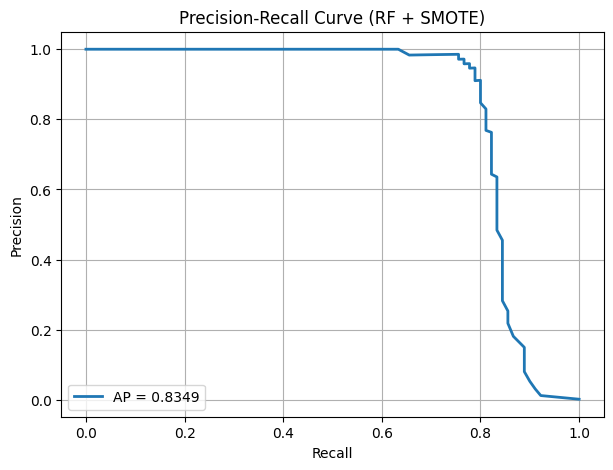

In [42]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, lw=2, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (RF + SMOTE)")
plt.grid(True)
plt.legend()
plt.savefig("../visuals/Precision-Recall Curve (RF + SMOTE).png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

In [43]:
# Compute F1-score for every threshold
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold : {best_threshold:.4f}")
print(f"Best Precision : {precision[best_idx]:.4f}")
print(f"Best Recall    : {recall[best_idx]:.4f}")
print(f"Best F1-score  : {f1_scores[best_idx]:.4f}")

Best Threshold : 0.5100
Best Precision : 0.9467
Best Recall    : 0.7889
Best F1-score  : 0.8606


In [44]:
# Default threshold = 0.5
y_pred_default = (y_prob >= 0.5).astype(int)

# Optimized threshold
y_pred_best = (y_prob >= best_threshold).astype(int)

print("=" * 60)
print("Default Threshold = 0.5")
print("=" * 60)
print(classification_report(y_test, y_pred_default))

print("\n" + "=" * 60)
print(f"Best Threshold = {best_threshold:.4f}")
print("=" * 60)
print(classification_report(y_test, y_pred_best))

Default Threshold = 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.93      0.79      0.86        90

    accuracy                           1.00     56746
   macro avg       0.97      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746


Best Threshold = 0.5100
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.95      0.79      0.86        90

    accuracy                           1.00     56746
   macro avg       0.97      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746



Threshold tuning confirmed that 0.51 is the optimal decision boundary. Precision improved marginally from 0.93 to 0.95 while recall remained stable at 0.79, confirming RF + SMOTE is already well calibrated.

## **SHAP explainability**

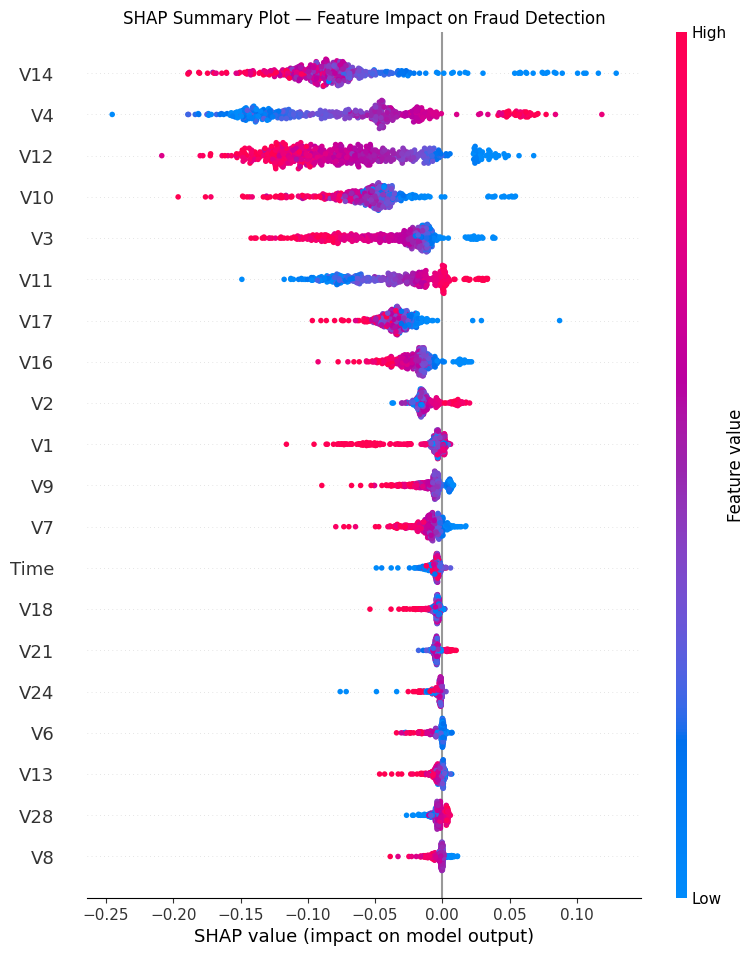

In [45]:
# Get the model
rf_model = rf_pipeline.named_steps["model"]

# Convert test data to DataFrame
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Take 500 samples
X_test_sample = X_test_df.sample(500, random_state=42)

# Create SHAP explainer
explainer = shap.Explainer(rf_model)

# Calculate SHAP values
shap_values = explainer(X_test_sample)

# Plot SHAP values for fraud
plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_sample,
    show=False
)

# Add title
plt.title("SHAP Summary Plot — Feature Impact on Fraud Detection")

# Save the plot
plt.savefig(
    "../visuals/shap_rf_smote.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()